In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

# Impostiamo lo stile dei grafici per renderli puliti e professionali
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Connessione al database per estrarre il dataset completo per l'EDA
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',  # Inserisci la tua password di MySQL
    database='aire_db'
)

# Estraiamo le misurazioni agganciate ai nomi delle stazioni
query = """
SELECT m.id, s.nome AS stazione, m.data, m.inquinante_codice AS inquinante, m.valore 
FROM misurazione_giornaliera m
JOIN stazione s ON m.stazione_id = s.id_amat
"""

df = pd.read_sql(query, conn)
conn.close()

# Mostra le prime 5 righe per verificare che i dati ci siano
df.head()

C:\Users\Eugenio\AppData\Local\Temp\ipykernel_14152\4258577904.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,stazione,data,inquinante,valore
0,741,via Pascal *,2026-02-10,C6H6,1.9
1,742,via Pascal *,2026-02-10,NO2,58.0
2,743,via Pascal *,2026-02-10,O3,48.0
3,744,via Pascal *,2026-02-10,PM10,40.0
4,745,via Pascal *,2026-02-10,PM25,27.0


In [ ]:
# Assicuriamoci che la colonna 'data' sia formato datetime
df['data'] = pd.to_datetime(df['data'])

# Convertiamo 'valore' in numero (se ci sono errori li fa diventare NaN)
df['valore'] = pd.to_numeric(df['valore'], errors='coerce')

# Rimuoviamo eventuali righe vuote per non sfasare i grafici
df = df.dropna(subset=['valore'])

print(f"Dati puliti e pronti. Totale misurazioni analizzabili: {len(df)}")

Dati puliti e pronti. Totale misurazioni analizzabili: 719


C:\Users\Eugenio\AppData\Local\Temp\ipykernel_14152\184841067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='inquinante', y='valore', palette='viridis')


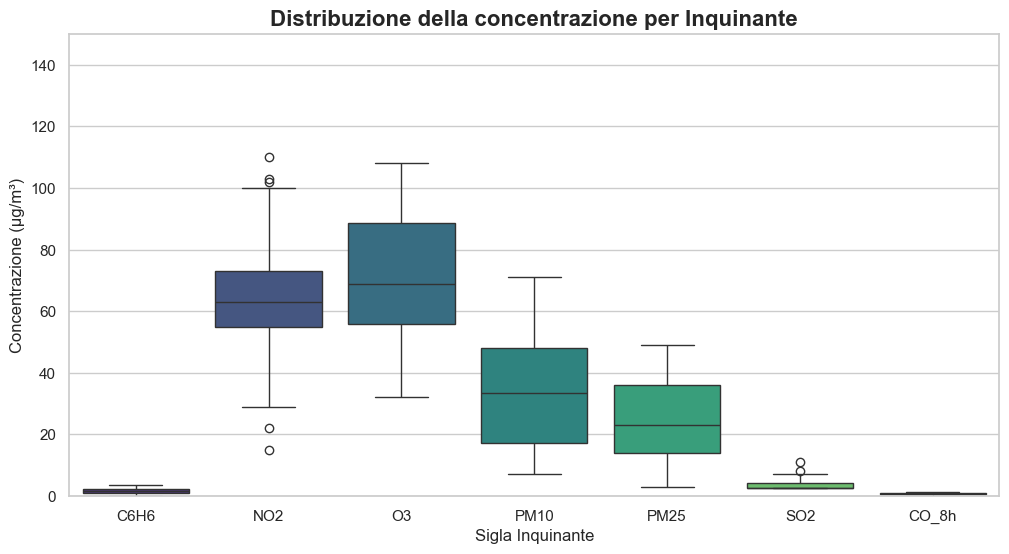

In [3]:
# Grafico 1: Distribuzione degli inquinanti
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='inquinante', y='valore', palette='viridis')

plt.title('Distribuzione della concentrazione per Inquinante', fontsize=16, fontweight='bold')
plt.xlabel('Sigla Inquinante', fontsize=12)
plt.ylabel('Concentrazione (µg/m³)', fontsize=12)

# Mettiamo un limite sull'asse Y per evitare che valori estremi schiaccino i grafici
plt.ylim(0, 150) 
plt.show()

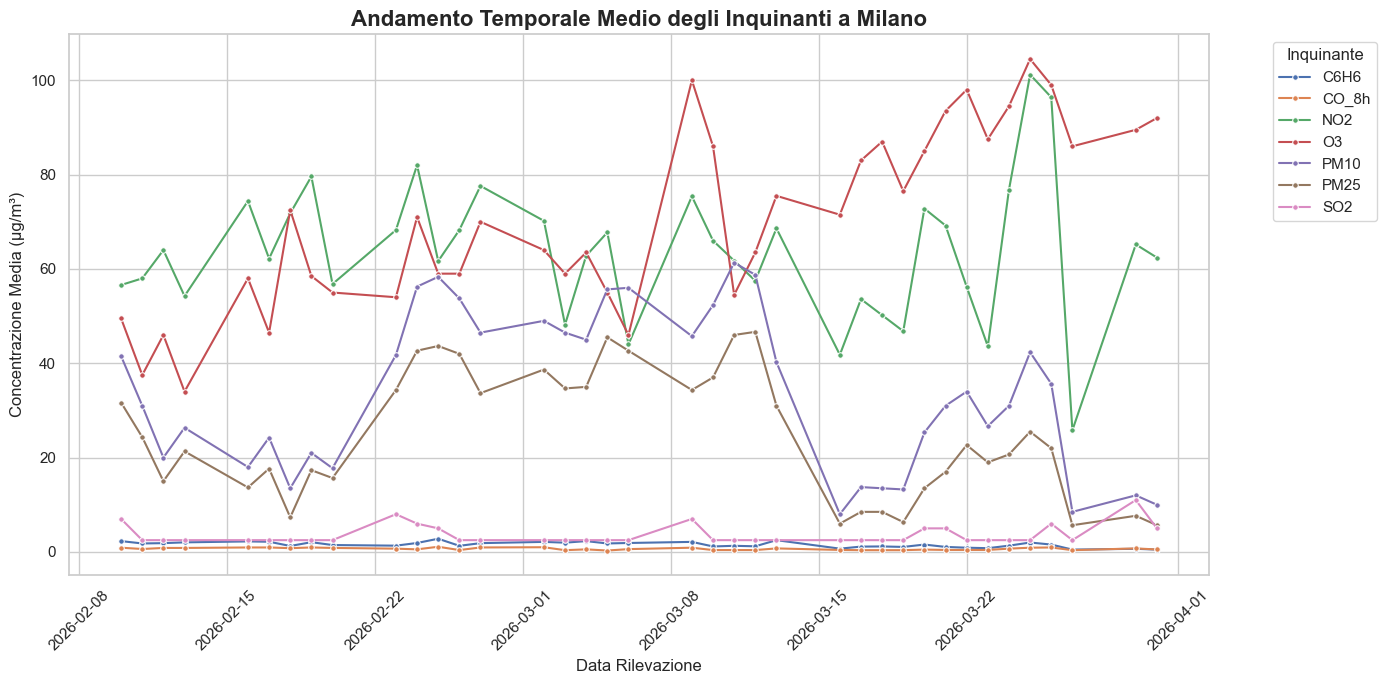

In [4]:
# Calcoliamo la media giornaliera su tutta la città
df_andamento = df.groupby(['data', 'inquinante'])['valore'].mean().reset_index()

# Grafico 2: Andamento Temporale
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_andamento, x='data', y='valore', hue='inquinante', marker='o', markersize=4)

plt.title('Andamento Temporale Medio degli Inquinanti a Milano', fontsize=16, fontweight='bold')
plt.xlabel('Data Rilevazione', fontsize=12)
plt.ylabel('Concentrazione Media (µg/m³)', fontsize=12)
plt.xticks(rotation=45)

# Spostiamo la legenda fuori dal grafico per non coprire le linee
plt.legend(title='Inquinante', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

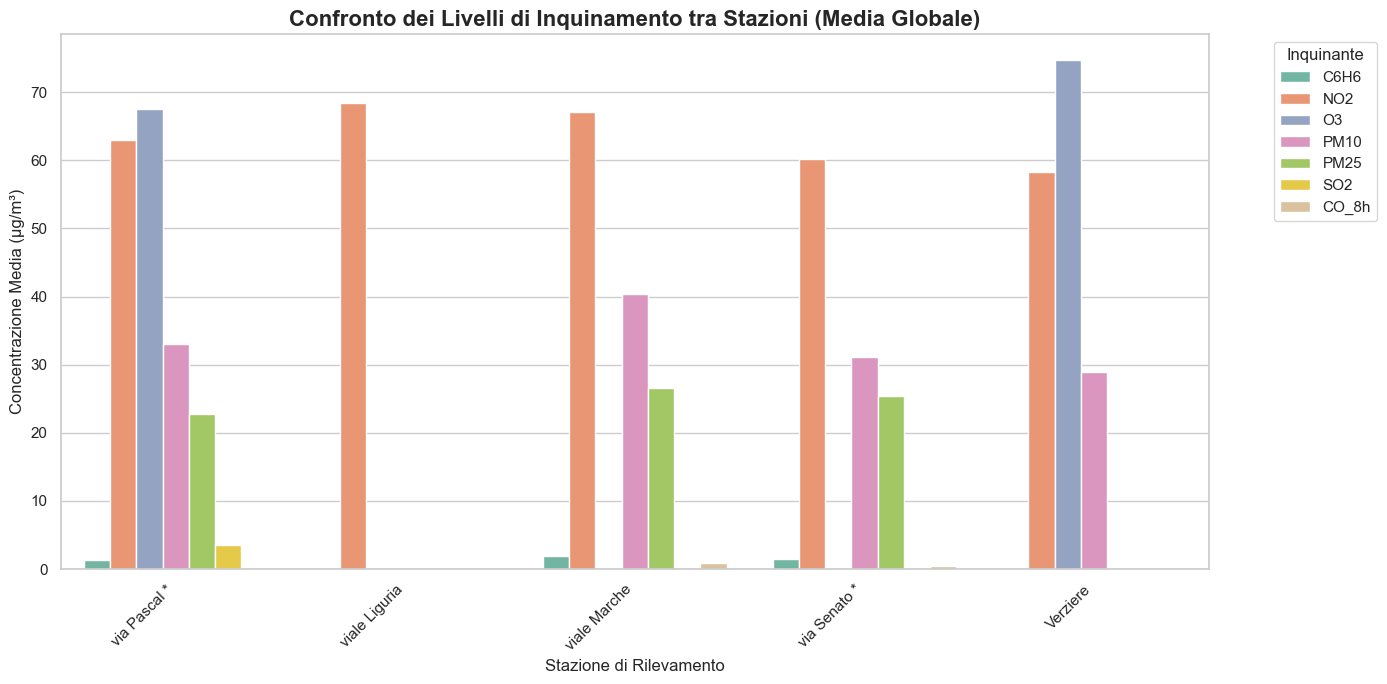

In [5]:
# Grafico 3: Confronto dei livelli medi tra le diverse stazioni
plt.figure(figsize=(14, 7))

# Creiamo un barplot che mostra il valore medio per stazione, diviso per inquinante
sns.barplot(data=df, x='stazione', y='valore', hue='inquinante', errorbar=None, palette='Set2')

plt.title('Confronto dei Livelli di Inquinamento tra Stazioni (Media Globale)', fontsize=16, fontweight='bold')
plt.xlabel('Stazione di Rilevamento', fontsize=12)
plt.ylabel('Concentrazione Media (µg/m³)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.legend(title='Inquinante', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

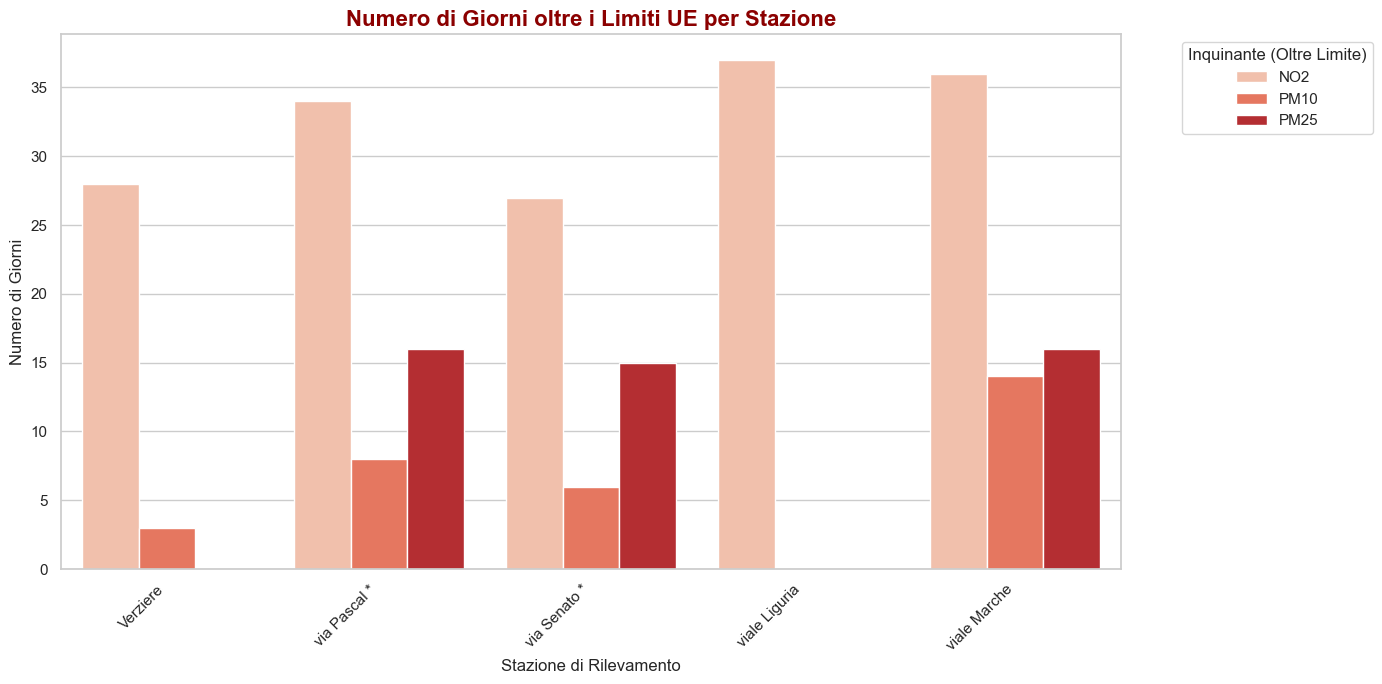

In [6]:
# 1. Definiamo le regole (Filtriamo i superamenti)
condizione_pm10 = (df['inquinante'] == 'PM10') & (df['valore'] > 50)
condizione_pm25 = (df['inquinante'] == 'PM25') & (df['valore'] > 25)
condizione_no2 = (df['inquinante'] == 'NO2') & (df['valore'] > 40)

# 2. Creiamo un nuovo DataFrame contenente SOLO i dati fuori norma
df_superamenti = df[condizione_pm10 | condizione_pm25 | condizione_no2]

# 3. Contiamo quanti giorni di superamento ci sono stati per ogni stazione
conteggio_stazioni = df_superamenti.groupby(['stazione', 'inquinante']).size().reset_index(name='giorni_oltre_limite')

# Grafico 4: Visualizzazione dei superamenti
plt.figure(figsize=(14, 7))
sns.barplot(data=conteggio_stazioni, x='stazione', y='giorni_oltre_limite', hue='inquinante', palette='Reds')

plt.title('Numero di Giorni oltre i Limiti UE per Stazione', fontsize=16, fontweight='bold', color='darkred')
plt.xlabel('Stazione di Rilevamento', fontsize=12)
plt.ylabel('Numero di Giorni', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.legend(title='Inquinante (Oltre Limite)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()